<a target="_blank" href="https://colab.research.google.com/github/paulotguerra/QXD0178/blob/main/03.E0-Exercicio-Agrupamento-de-Dados.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

## QXD0178 - Mineração de Dados
# Visualização de Dados

**Professor:** Marcos Antonio de Oliveira ([marcos.oliveira@ufc.br](mailto:marcos.oliveira@ufc.br))


# Lista de Exercícios: Visualização de Dados

Para este projeto, você exercítará a visualização de dados por meio do dataset [311 Complaint Data](https://data.cityofnewyork.us/Social-Services/311-Service-Requests-from-2010-to-Present/erm2-nwe9) do New York City Open Data Portal. Você formulará uma pergunta de pesquisa que pode ser abordada por meio dos dados e identificará o público que se beneficiaria de sua pesquisa. Por exemplo, sua investigação pode permitir que um grupo comunitário priorize seus esforços ou ajude indivíduos a decidir onde morar. Seja criativo e pense em quem você quer servir com seu trabalho.

Ao final deste projeto, você será capaz de:

- Acessar e explorar uma fonte de dados pública
- Formular uma questão de pesquisa que um conjunto de dados específico pode abordar
- Criar uma visualização precisa e bem pensada usando matplotlib, seaborn, plotly, entre outros
- Contextualizar o processo e o escopo do seu trabalho

## Processo de Visualização de Dados

Sua proposta deve delinear estas quatro dimensões:

- **Sua pergunta de pesquisa**. Sua pergunta de pesquisa pode assumir a forma de uma pergunta, tópico ou título, mas deve ser respondida por este conjunto de dados e por meio de uma visualização. Sua pergunta de pesquisa se desenvolverá à medida que você trabalha com o conjunto de dados. Por exemplo, seu projeto pode começar com "Qual mês tem mais reclamações de aquecimento?" e ​​então expandir para "Qual(is) ano(s) teve(tiveram) mais reclamações de aquecimento e quais edifícios são reincidentes?" Inclua sua motivação para a pergunta. Por que as reclamações de aquecimento são importantes? O que podemos inferir da resposta a esta pergunta?
- **Seu público**. Quem se beneficiaria de uma resposta à sua pergunta de pesquisa? Por que essa pergunta é importante para eles? Você pode dar contexto narrativo ou uma declaração muito direta do que está em jogo. Por exemplo, "Entender as reclamações sobre aquecimento é importante para o Departamento de Saúde Pública. Ao entender melhor quando as reclamações sobre aquecimento atingem o pico, eles podem direcionar melhor os recursos para ajudar aqueles que estão em maior risco." Ao começar a projetar sua visualização, considere qual funcionalidade (como filtros ou dicas de ferramentas) beneficiaria mais esse público.
- **Uma descrição escrita de suas visualizações**. Explique suas visualizações em termos que um novato em dados entenderia. Em uma frase para um parágrafo, que conclusão devo tirar de sua visualização?
- **Uma explicação dos dados e decisões de design que você tomou**. Esta seção deve ilustrar o que você fez e por que fez. Por que você escolheu o tipo de gráfico/gráfico/visualização que fez? Como essa escolha representa melhor os dados e aborda sua pergunta? Por meio dessa explicação, você ilustrará que as decisões que tomou foram intencionais e como elas contribuem para o projeto. Você também deve explicar quaisquer limitações que encontrou e quaisquer compromissos subsequentes que fez com os dados ou seu design.


### **Critérios de Avaliação**  

**1. Escolha Apropriada de Visualização (4 pontos)**  
- O tipo de visualização está alinhado com a questão da pesquisa.  
- O gráfico ou tabela escolhidos representam os dados com precisão e de forma adequada.  

**2. Comunicação Eficaz (2 pontos)**  
- A mensagem principal da análise é comunicada de forma clara e compreensível.  
- Os dados são apresentados com precisão, sem distorções ou interpretações enganosas.  

**3. Design e Estética (2 pontos)**  
- Todos os elementos da visualização têm uma função comunicativa e não são apenas decorativos.  
- A organização do notebook e o layout das visualizações seguem uma estrutura lógica e intencional.  
- Títulos, legendas e rótulos são informativos, bem posicionados e utilizam tamanhos e grafias apropriados.  

**4. Qualidade da Documentação (2 pontos)**  
- O notebook fornece um contexto claro que torna as visualizações mais compreensíveis e acessíveis.  
- O notebook explica o propósito da análise e as decisões tomadas no processo de criação.  
- Todos os componentes essenciais (pergunta de pesquisa, definição do público, explicação das escolhas, análise das visualizações e próximos passos) estão incluídos.  
- As decisões seguem boas práticas de visualização de dados.  

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [ ]:
def carregar_dados_api(limite=50000):
    url = "https://data.cityofnewyork.us/resource/erm2-nwe9.json"
    
    params = {
        "$limit": limite,            
        "$where": "created_date > '2025-01-01T00:00:00'",
        "$order": "created_date DESC",
        "$select": "unique_key, created_date, complaint_type, borough, city" 
    }
    
    print(f"Baixando {limite} registros da API... aguarde um momento.")
    
    try:
        response = requests.get(url, params=params)
        response.raise_for_status()
        
        df = pd.DataFrame(response.json())
        
        df.rename(columns={
            'unique_key': 'Unique Key',
            'created_date': 'Created Date',
            'complaint_type': 'Complaint Type',
            'borough': 'Borough',
            'city': 'City'
        }, inplace=True)
        
        print(f"Sucesso! {len(df)} linhas carregadas.")
        return df
        
    except Exception as e:
        print(f"Erro ao acessar a API: {e}")
        return pd.DataFrame()



In [ ]:
df = carregar_dados_api(limite=2000000)

Baixando 2000000 registros da API... aguarde um momento.
Sucesso! 2000000 linhas carregadas.


In [4]:
df['Created Date'] = pd.to_datetime(df['Created Date'])
df['Month'] = df['Created Date'].dt.month_name()
df['Hour'] = df['Created Date'].dt.hour

### 1. Pergunta de Pesquisa
Título: Diagnóstico da Qualidade de Vida Urbana: Uma Análise das Reclamações de Serviços em Nova York.

Pergunta: Quais são os problemas urbanos mais críticos relatados pelos cidadãos de Nova York recentemente e existe um padrão geográfico ou temporal específico para a incidência de poluição sonora (reclamações de barulho)?

Motivação: As solicitações via 311 funcionam como um termômetro da satisfação e das necessidades da população. Identificar os tipos de reclamações mais frequentes não é apenas uma curiosidade estatística, mas uma necessidade de saúde pública e gestão urbana. Especificamente, o foco em "barulho" é motivado pelo fato de a poluição sonora ser um dos maiores estressores em ambientes urbanos densos, afetando diretamente a saúde mental e a qualidade do sono dos residentes. Inferir onde e quando esses problemas ocorrem permite passar de uma gestão reativa para uma gestão preventiva.

### 2. Público Alvo
Esta análise foi projetada para beneficiar principalmente o Departamento de Proteção Ambiental de NYC (DEP) e os Conselhos Comunitários Locais.

O que está em jogo: Para o DEP e a polícia de NY, recursos de fiscalização são limitados. Saber que o barulho é o problema número 1 e que ele se concentra, por exemplo, em Manhattan durante certos horários ou meses, permite uma alocação de patrulhas e fiscais baseada em dados, e não em suposições.

Contexto: Para os Conselhos Comunitários, visualizar esses dados ajuda a pleitear verbas específicas para infraestrutura (como isolamento acústico ou controle de tráfego) em distritos que são estatisticamente mais afetados.

### 3. Descrição das Visualizações
As visualizações apresentadas contam a história das demandas da cidade em três atos, pensados para serem compreendidos por qualquer cidadão:

O "O Quê" (Ranking de Problemas): O primeiro gráfico mostra claramente quais são as 5 maiores dores de cabeça dos nova-iorquinos. A conclusão imediata é identificar se o maior volume de trabalho da prefeitura deve ser focado em infraestrutura (como água quente) ou ordem pública (como barulho e estacionamento ilegal).

O "Onde" (Foco no Barulho): Ao isolarmos as reclamações de barulho, o segundo gráfico revela qual distrito (Borough) é o mais "barulhento". Um leigo pode olhar para isso e entender rapidamente onde a qualidade do sono é mais prejudicada.

O "Quando" (Tendência): O terceiro gráfico mostra a linha do tempo das reclamações. A conclusão a ser tirada é se existe uma sazonalidade (ex: reclamações aumentam no verão quando as janelas estão abertas?) ou se o volume de problemas está crescendo ou diminuindo ao longo do ano.

C:\Users\luizm\AppData\Local\Temp\ipykernel_21196\4286946612.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(x=top_complaints.values, y=top_complaints.index, palette='viridis')


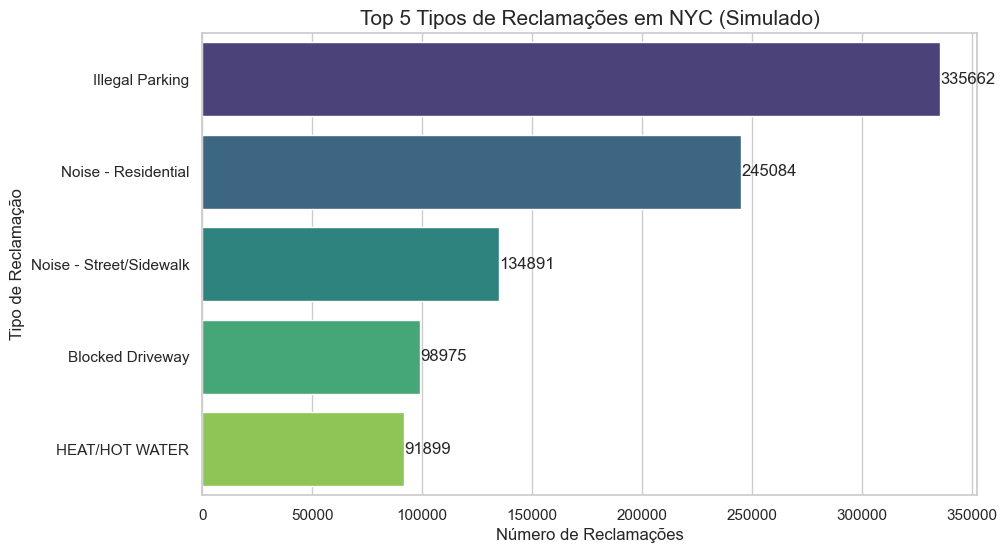

In [5]:
plt.figure(figsize=(10, 6))
top_complaints = df['Complaint Type'].value_counts().nlargest(5)
ax1 = sns.barplot(x=top_complaints.values, y=top_complaints.index, palette='viridis')
plt.title('Top 5 Tipos de Reclamações em NYC (Simulado)', fontsize=15)
plt.xlabel('Número de Reclamações')
plt.ylabel('Tipo de Reclamação')
for i in ax1.containers:
    ax1.bar_label(i,)
plt.show()

Optei por um Gráfico de Barras Horizontais para o ranking de reclamações. Como os nomes das categorias são longos (ex: "Noise - Residential"), barras verticais tornariam a leitura difícil ou exigiriam rotação de texto. A orientação horizontal facilita a leitura imediata dos rótulos.

C:\Users\luizm\AppData\Local\Temp\ipykernel_21196\1685220740.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.countplot(data=noise_df, x='Borough', palette='magma',


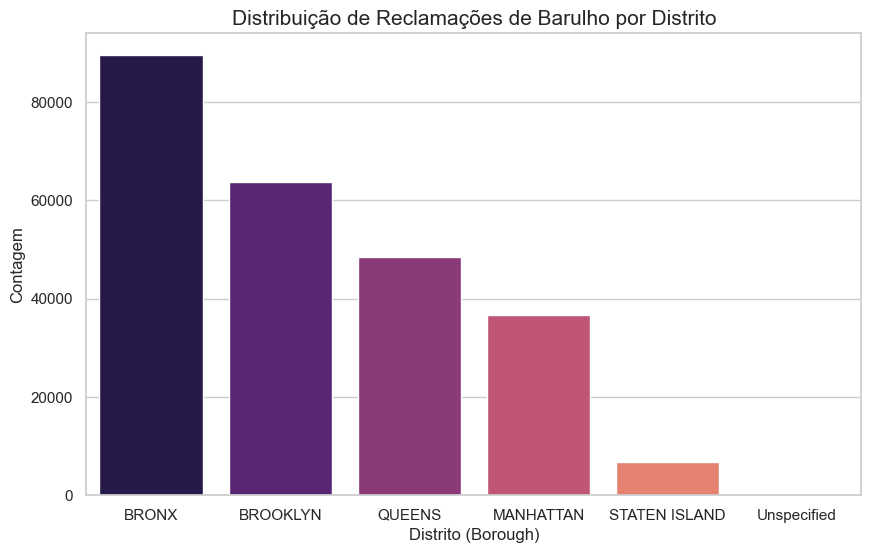

In [6]:
plt.figure(figsize=(10, 6))
noise_df = df[df['Complaint Type'] == 'Noise - Residential']
ax2 = sns.countplot(data=noise_df, x='Borough', palette='magma', 
                    order=noise_df['Borough'].value_counts().index)
plt.title('Distribuição de Reclamações de Barulho por Distrito', fontsize=15)
plt.xlabel('Distrito (Borough)')
plt.ylabel('Contagem')
plt.show()

Para a comparação entre distritos, usei Barras Verticais com uma paleta de cores distinta (magma), pois estamos comparando volumes entre categorias discretas (os 5 distritos).

C:\Users\luizm\AppData\Local\Temp\ipykernel_21196\2552033773.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_counts = df.groupby('Month').size()


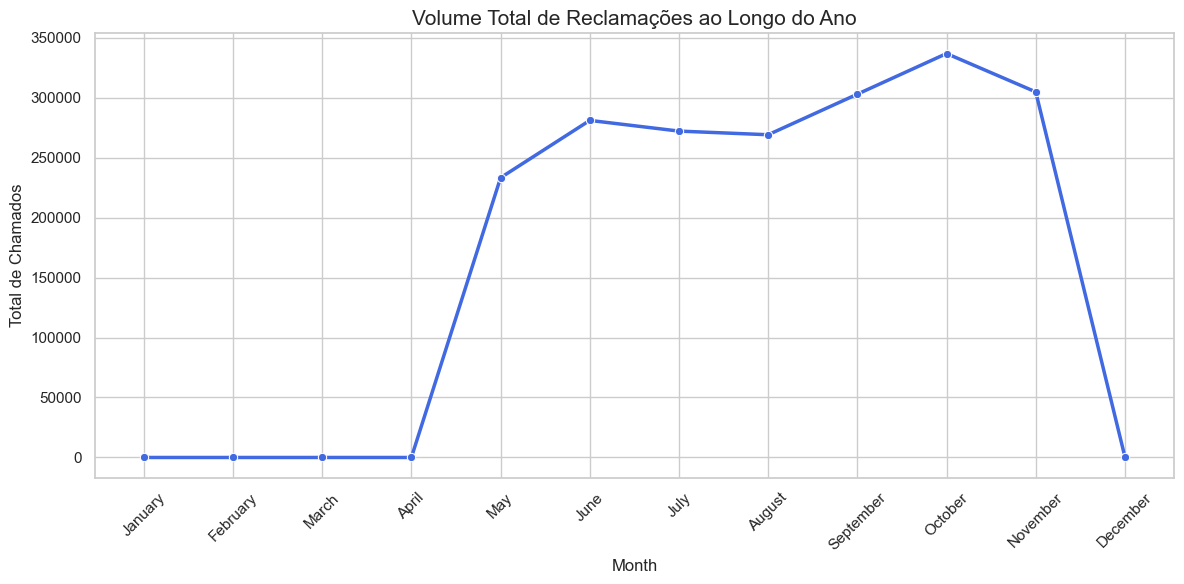

In [7]:
plt.figure(figsize=(12, 6))
# Agrupar por mês (ordem correta)
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 
                'July', 'August', 'September', 'October', 'November', 'December']
df['Month'] = pd.Categorical(df['Month'], categories=months_order, ordered=True)
monthly_counts = df.groupby('Month').size()

sns.lineplot(x=monthly_counts.index, y=monthly_counts.values, marker='o', linewidth=2.5, color='royalblue')
plt.title('Volume Total de Reclamações ao Longo do Ano', fontsize=15)
plt.xticks(rotation=45)
plt.ylabel('Total de Chamados')
plt.tight_layout()
plt.show()

Para a análise temporal, utilizei um Gráfico de Linha. Esta é a convenção padrão para séries temporais, pois a conexão entre os pontos sugere continuidade e permite ao olho humano detectar tendências de alta ou baixa instantaneamente.

Uma limitação importante é que, devido ao volume massivo de dados históricos (milhões de linhas), optamos por extrair via API apenas as reclamações mais recentes (limitadas a 2.000.000 linhas). Isso significa que nossa análise reflete o cenário atual da cidade, e não necessariamente tendências de longo prazo (como a última década).

In [8]:
df.to_csv('dados_nyc_311_parciais.csv', index=False)